In [1]:
# ================================================================
# Stress Testing & Scenario Analysis — Starter Notebook
# Folder: 03_stress_testing/stress_testing.ipynb
# ================================================================

# 0) Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (9,5)

DATA_PATH = Path("../porfolio-risk/data")  # adjust if needed


In [2]:
# 1) Load price data ------------------------------------------------
# Expected real CSV format: index=Date (YYYY-MM-DD), columns=tickers, values=adj close
# Example: prices = pd.read_csv(DATA_PATH/"prices.csv", parse_dates=["Date"], index_col="Date").sort_index()

try:
    
# read your csv
    df = pd.read_csv(DATA_PATH/"prices.csv", index_col=0)

    # keep only columns with "Close" in their name
    df = df.filter(like="Close")

    # the tickers are in the last row ("Ticker")
    tickers = df.loc["Ticker"]

    # drop the last two rows ("Date" and "Ticker")
    df = df.drop(["Date", "Ticker"])

    # set proper column names
    df.columns = tickers.values

    # convert index to datetime
    df.index = pd.to_datetime(df.index)

    # cast values to float
    df = df.astype(float)

    # optional: sort by date
    df = df.sort_index()
    print(f"Loaded real data with shape: {df.shape}")
except Exception as e:
    print("Could not find real data, generating synthetic sample…")
    np.random.seed(42)
    dates = pd.date_range("2015-01-01", periods=2600, freq="B")
    tickers = ["EQ_US","EQ_EU","BOND_GOV_EUR","BOND_CORP_EUR","GOLD","USD_EUR"]
    prices = pd.DataFrame(
        np.cumprod(1 + np.random.normal([0.00025,0.0002,0.00008,0.0001,0.00012,0.0000],
                                        [0.012,0.011,0.003,0.004,0.009,0.002],
                                        size=(len(dates), len(tickers))), axis=0)*100,
        index=dates, columns=tickers
    )

Loaded real data with shape: (1763, 15)


In [3]:
df_cleaned = df.dropna(how='all')  # drop rows where all values are NaN


print(df_cleaned.head(50))

             ENEL.MI    ENI.MI    EUNL.DE    IDVY.MI  IGCB.L    ISP.MI  \
Price                                                                    
2019-01-02  3.419653  8.836534  43.401001  13.807296     NaN  1.192991   
2019-01-03  3.420998  8.875010  42.841999  13.788765     NaN  1.189862   
2019-01-04  3.468082  9.195638  43.756001  14.083788     NaN  1.251063   
2019-01-07  3.466737  9.114840  44.063000  14.056708     NaN  1.272215   
2019-01-08  3.481535  9.058410  44.214001  14.117989     NaN  1.257509   
2019-01-09  3.473463  9.141772  44.403999  14.189249     NaN  1.255632   
2019-01-10  3.531309  9.132794  44.582001  14.192100     NaN  1.264705   
2019-01-11  3.497678  9.086625  44.707001  14.216328     NaN  1.258448   
2019-01-14  3.504404  9.054562  44.583000  14.193521     NaN  1.240175   
2019-01-15  3.511130  9.137925  45.091999  14.193521     NaN  1.224655   
2019-01-16  3.509785  9.157164  45.403999  14.323218     NaN  1.270337   
2019-01-17  3.524582  9.117407  45.459

In [4]:
# 2) Returns & helper functions ------------------------------------
#df_filled = df.ffill()           # fill missing prices
rets = df.pct_change(fill_method=None).dropna()

def max_drawdown(series: pd.Series):
    cum = (1+series).cumprod()
    peak = cum.cummax()
    dd = (cum/peak-1)
    return dd.min(), dd

def portfolio_series(returns: pd.DataFrame, weights: pd.Series):
    w = weights.reindex(returns.columns).fillna(0).values
    return (returns @ w)

def var_cvar(series: pd.Series, level=0.95):
    # Historical VaR/CVaR on daily returns
    q = series.quantile(1-level)
    cvar = series[series <= q].mean()
    return float(q), float(cvar)

No weights file found — using equal weights across all assets.


,weight
ENEL.MI,0.066667
ENI.MI,0.066667
EUNL.DE,0.066667
IDVY.MI,0.066667
IGCB.L,0.066667
ISP.MI,0.066667
IUKD.L,0.066667
MSFT,0.066667
NVDA,0.066667
PST.MI,0.066667


Baseline | Ann Ret: 20.56% | Ann Vol: 15.74% | VaR95 (daily): -1.41% | CVaR95: -2.36% | MaxDD: -24.36%


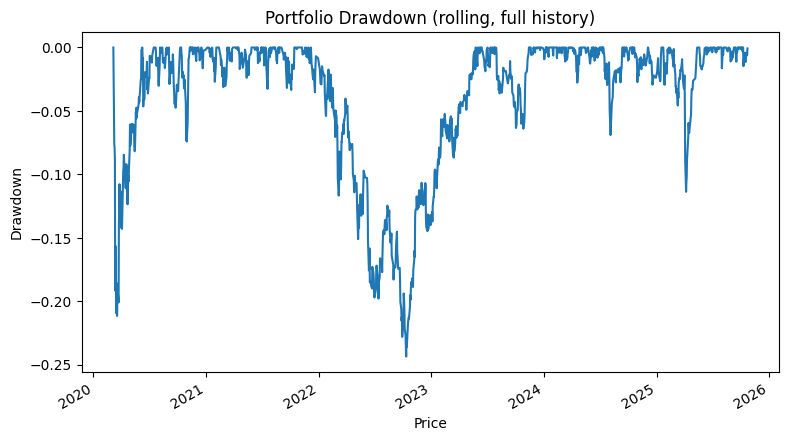

In [5]:
# 3) Portfolio weights ---------------------------------------------
# Option A: load from a CSV produced by mean_variance/report.csv (ticker,weight)
# Expected format: two columns: ticker, weight (no header names required if you adapt)
weights_path_candidates = [Path("../portfolio-optimisation/weights.csv")]

weights=None
for p in weights_path_candidates:
    if p.exists():
        tmp = pd.read_csv(p, index_col=0)
        # If report.csv had KPIs at bottom, keep only tickers where weight>0 and index not meta
        tmp.columns = tmp.columns.str.strip()  # remove any stray spaces
        # Use the first column as weights, regardless of its name
        weights = tmp.iloc[:, 0]
        break

if weights is None:
    print("No weights file found — using equal weights across all assets.")
    weights = pd.Series(1/len(rets.columns), index=rets.columns)

weights = weights / weights.sum()
display(weights.to_frame("weight"))

# 4) Baseline portfolio stats --------------------------------------
port_daily = portfolio_series(rets, weights)
ann_ret = (1+port_daily.mean())**252 - 1
ann_vol = port_daily.std()*np.sqrt(252)
v95, cv95 = var_cvar(port_daily, 0.95)
mdd, dd_series = max_drawdown(port_daily)

print(f"Baseline | Ann Ret: {ann_ret:.2%} | Ann Vol: {ann_vol:.2%} | VaR95 (daily): {v95:.2%} | CVaR95: {cv95:.2%} | MaxDD: {mdd:.2%}")

plt.figure()
dd_series.plot()
plt.title("Portfolio Drawdown (rolling, full history)")
plt.ylabel("Drawdown")
plt.show()



,scenario,days,cum_return,min_dd,VaR95,CVaR95
0,GFC_2008,0,NaN,NaN,NaN,NaN
1,COVID_2020,37,-0.099126,-0.211589,-0.065768,-0.094845
2,Rates_Selloff_2022,188,-0.177704,-0.232213,-0.020243,-0.025191


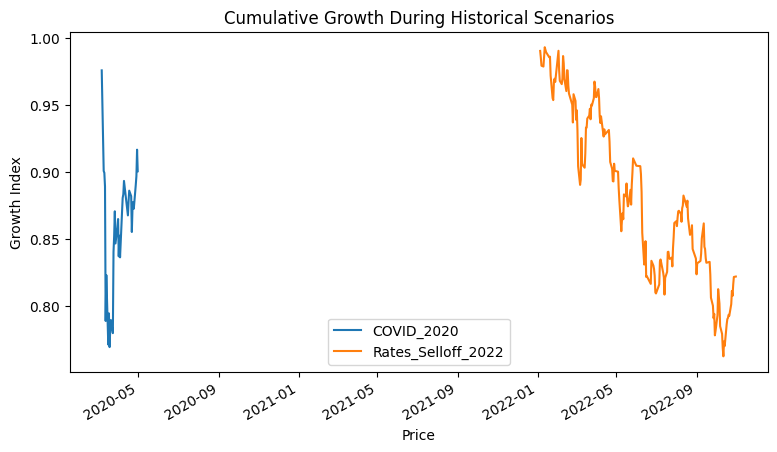

,scenario,one_day_port_return
0,EQ_-20_BONDS_+2%y,0.0
1,Energy_Spike_SafeHaven,0.0


Saved: baseline_stats.csv, historical_scenario_results.csv, hypothetical_scenario_results.csv, weights_used.csv


In [6]:
# 5) Scenario definitions ------------------------------------------
# (A) Historical windows (adjust dates to your data)
historical_scenarios = {
    "GFC_2008": ("2008-09-01","2009-03-31"),
    "COVID_2020": ("2020-02-15","2020-04-30"),
    "Rates_Selloff_2022": ("2022-01-01","2022-10-31")
}

# (B) Hypothetical shocks: dictionary mapping tickers to instantaneous return shocks
# Adjust keys to your column names
hypothetical_scenarios = {
    "EQ_-20_BONDS_+2%y": {
        "EQ_US": -0.20, "EQ_EU": -0.20,
        "BOND_GOV_EUR": -0.06, "BOND_CORP_EUR": -0.08,
        "GOLD": 0.03, "USD_EUR": 0.02
    },
    "Energy_Spike_SafeHaven": {
        "EQ_US": -0.10, "EQ_EU": -0.12,
        "BOND_GOV_EUR": 0.02, "BOND_CORP_EUR": -0.02,
        "GOLD": 0.08, "USD_EUR": 0.01
    }
}

# 6) Apply historical scenarios ------------------------------------
hist_results = []
for name,(start,end) in historical_scenarios.items():
    sub = rets.loc[start:end]
    if sub.empty:
        hist_results.append({"scenario":name,"days":0,"cum_return":np.nan,"min_dd":np.nan,"VaR95":np.nan,"CVaR95":np.nan})
        continue
    p = portfolio_series(sub, weights)
    cum = (1+p).prod()-1
    v95_s, cv95_s = var_cvar(p, 0.95)
    mdd_s, _ = max_drawdown(p)
    hist_results.append({"scenario":name,"days":len(sub),"cum_return":cum,"min_dd":mdd_s,"VaR95":v95_s,"CVaR95":cv95_s})

hist_df = pd.DataFrame(hist_results)
display(hist_df)

plt.figure()
for name,(start,end) in historical_scenarios.items():
    sub = rets.loc[start:end]
    if sub.empty: 
        continue
    p = portfolio_series(sub, weights)
    (1+p).cumprod().plot(label=name)
plt.title("Cumulative Growth During Historical Scenarios")
plt.legend(); plt.ylabel("Growth Index"); plt.show()

# 7) Apply hypothetical instantaneous shocks -----------------------
hypo_results = []
for name,shock_map in hypothetical_scenarios.items():
    shocked_asset_returns = pd.Series(0.0, index=rets.columns)
    for tkr,val in shock_map.items():
        if tkr in shocked_asset_returns.index:
            shocked_asset_returns.loc[tkr] = val
    port_shock = float((shocked_asset_returns @ weights.reindex(shocked_asset_returns.index).fillna(0)))
    hypo_results.append({"scenario":name,"one_day_port_return":port_shock})

hypo_df = pd.DataFrame(hypo_results)
display(hypo_df)

# 8) Save results ---------------------------------------------------
out = {
    "baseline": {
        "ann_return": ann_ret, "ann_vol": ann_vol, "VaR95_daily": v95, "CVaR95_daily": cv95, "maxDD": mdd
    }
}
pd.Series(out["baseline"]).to_csv("baseline_stats.csv")
hist_df.to_csv("historical_scenario_results.csv", index=False)
hypo_df.to_csv("hypothetical_scenario_results.csv", index=False)
weights.to_frame("weight").to_csv("weights_used.csv")
print("Saved: baseline_stats.csv, historical_scenario_results.csv, hypothetical_scenario_results.csv, weights_used.csv")


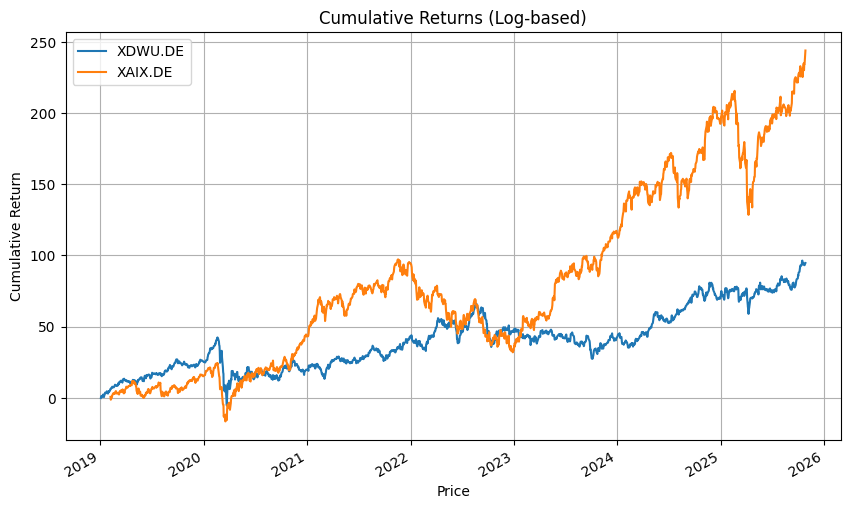

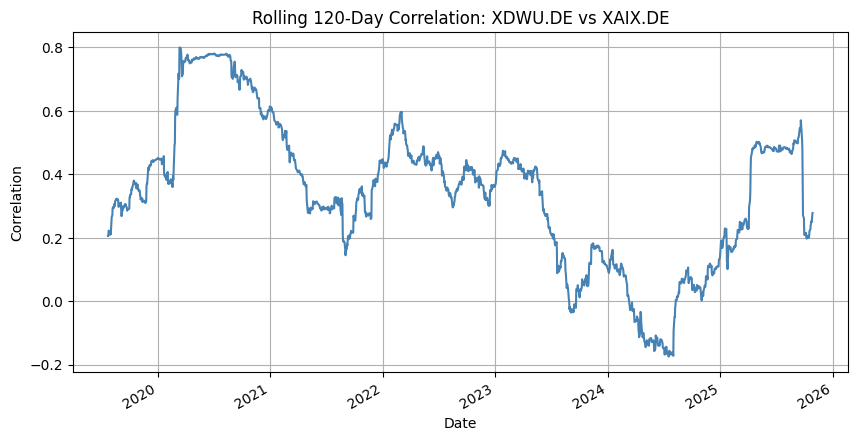

In [7]:
# Pick two assets
ticker_1 = df_cleaned['XDWU.DE'].ffill()
ticker_2 = df_cleaned['XAIX.DE'].ffill()


# Compute log returns
logrets_ticker_1 = np.log(ticker_1 / ticker_1.shift(1))
logrets_ticker_2 = np.log(ticker_2 / ticker_2.shift(1))

# Cumulative returns from log returns
#cum_ticker_1 = np.exp(logrets_ticker_1.cumsum()) - 1
#cum_ticker_2 = np.exp(logrets_ticker_2.cumsum()) - 1
cum_ticker_1 = logrets_ticker_1.cumsum().apply(np.exp).sub(1).mul(100)
cum_ticker_2 = logrets_ticker_2.cumsum().apply(np.exp).sub(1).mul(100)
# Plot comparison
plt.figure(figsize=(10,6))
cum_ticker_1.plot(label=ticker_1.name)
cum_ticker_2.plot(label=ticker_2.name)
plt.title("Cumulative Returns (Log-based)")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

# Compute rolling correlation
rets = pd.concat([logrets_ticker_1, logrets_ticker_2], axis=1)
rets.columns = [ticker_1.name, ticker_2.name]

window = 120  # number of trading days in window
rolling_corr = rets[ticker_1.name].rolling(window).corr(rets[ticker_2.name])

plt.figure(figsize=(10,5))
rolling_corr.plot(color='steelblue')
plt.title(f"Rolling {window}-Day Correlation: {ticker_1.name} vs {ticker_2.name}")
plt.ylabel("Correlation")
plt.xlabel("Date")
plt.grid(True)
plt.show()

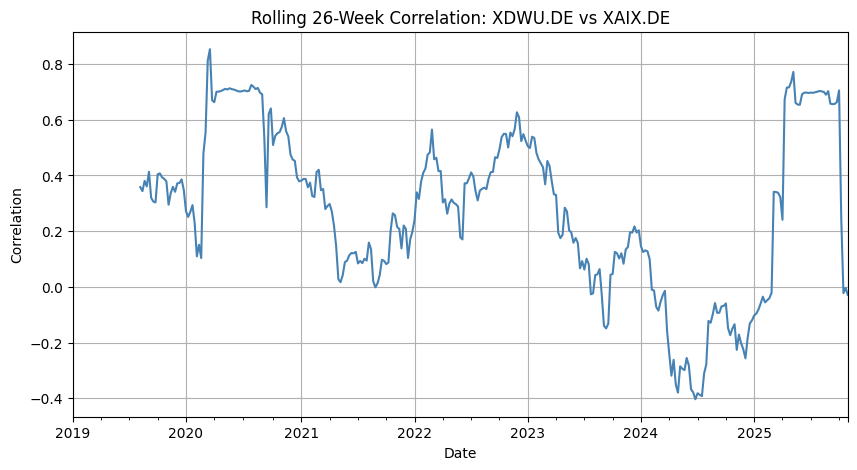

In [8]:
# weekly prices
ticker_1_w = ticker_1.resample('W-WED').last()
ticker_2_w = ticker_2.resample('W-WED').last()

# weekly log returns
logrets_ticker_1_w = np.log(ticker_1_w / ticker_1_w.shift(1))
logrets_ticker_2_w = np.log(ticker_2_w / ticker_2_w.shift(1))

# Compute rolling correlation
rets_w = pd.concat([logrets_ticker_1_w, logrets_ticker_2_w], axis=1)
rets_w.columns = [ticker_1.name, ticker_2.name]

window_w= 26  # number of trading weeks in window
rolling_corr = rets_w[ticker_1.name].rolling(window_w).corr(rets_w[ticker_2.name])

plt.figure(figsize=(10,5))
rolling_corr.plot(color='steelblue')
plt.title(f"Rolling {window_w}-Week Correlation: {ticker_1.name} vs {ticker_2.name}")
plt.ylabel("Correlation")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [9]:
trading_days = 252

print(logrets_ticker_1.mean() * trading_days * 100, logrets_ticker_2.mean() * trading_days * 100) # 
print(logrets_ticker_1.std() * np.sqrt(trading_days) * 100, logrets_ticker_2.std() * np.sqrt(trading_days) * 100) # 
print(logrets_ticker_1.min() * 100, logrets_ticker_2.min() * 100) # 
print(logrets_ticker_1.max() * 100, logrets_ticker_2.max() * 100) # 
print(logrets_ticker_1.quantile(0.25) * 100, logrets_ticker_2.quantile(0.25) * 100) # 

9.528593679120975 17.916878600224248
16.359290884288217 21.041698564654325
-9.976079125357222 -9.085232631231516
6.791258665787074 8.90132122164743
-0.45720071274080315 -0.5711569794532804
